In [50]:
import numpy as np

In [51]:
import pandas as pd

In [52]:
import matplotlib.pyplot as plt

In [53]:
import seaborn as sns

In [2]:
df = pd.read_csv('loan_approval_dataset.csv')

In [3]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [4]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [5]:
df[' education'].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [6]:
df[' self_employed'].unique()

array([' No', ' Yes'], dtype=object)

In [7]:
df1 = df.drop(['loan_id'],axis=1)

In [8]:
df1.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
le = LabelEncoder()

In [11]:
col = [' education',' self_employed',' loan_status']

In [12]:
df1[col] = df1[col].apply(le.fit_transform)

In [13]:
df1.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [14]:
df1.drop(col,axis=1).corr()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
no_of_dependents,1.000000,0.007266,-0.003366,-0.020111,-0.009998,0.007376,-0.001531,0.002817,0.011163
income_annum,0.007266,1.000000,0.927470,0.011488,-0.023034,0.636841,0.640328,0.929145,0.851093
loan_amount,-0.003366,0.927470,1.000000,0.008437,-0.017035,0.594596,0.603188,0.860914,0.788122
loan_term,-0.020111,0.011488,0.008437,1.000000,0.007810,0.008016,-0.005478,0.012490,0.017177
cibil_score,-0.009998,-0.023034,-0.017035,0.007810,1.000000,-0.019947,-0.003769,-0.028618,-0.015478
residential_assets_value,0.007376,0.636841,0.594596,0.008016,-0.019947,1.000000,0.414786,0.590932,0.527418
commercial_assets_value,-0.001531,0.640328,0.603188,-0.005478,-0.003769,0.414786,1.000000,0.591128,0.548576
luxury_assets_value,0.002817,0.929145,0.860914,0.012490,-0.028618,0.590932,0.591128,1.000000,0.788517
bank_asset_value,0.011163,0.851093,0.788122,0.017177,-0.015478,0.527418,0.548576,0.788517,1.000000


In [16]:
x = df1.drop([' loan_status'],axis=1)

In [17]:
y = df1[' loan_status']

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2)

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

In [22]:
col1 = [' no_of_dependents',' income_annum',' loan_amount',' loan_term',' cibil_score',' residential_assets_value',' commercial_assets_value',' luxury_assets_value',' bank_asset_value']

In [23]:
x_train[col1] = scaler.fit_transform(x_train[col1])

In [24]:
x_test[col1] = scaler.transform(x_test[col1])

In [25]:
x_train.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
3739,-1.487427,0,1,0.756682,0.741948,-1.199873,-0.900620,1.563091,1.330836,1.019795,0.796952
235,-0.896712,0,1,0.650275,0.906889,-1.199873,-0.697348,1.716455,-0.883079,0.899735,1.591166
2281,-0.305996,1,0,-0.662084,-0.720532,1.247479,0.214468,-0.998094,-0.024622,-0.715611,-0.455464
1482,-1.487427,1,1,-0.981306,-0.984438,-0.500630,0.644242,-0.108581,-0.747533,-0.693782,-1.066398
2297,0.875435,1,1,1.395127,1.753588,-0.500630,1.712868,-0.062572,-0.137577,0.899735,2.477021


In [26]:
from sklearn.tree import DecisionTreeClassifier

In [27]:
dt = DecisionTreeClassifier()

In [28]:
criterion = ['gini','entropy']
max_depth = [3,5,7,9,10,12]

In [29]:
para_grid = {
    'criterion' : criterion,
    'max_depth' : max_depth
}

In [30]:
print(para_grid)

{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, 7, 9, 10, 12]}


In [31]:
from sklearn.model_selection import GridSearchCV

In [32]:
grid_cv = GridSearchCV(estimator=dt,
                      param_grid=para_grid,
                       cv= 5
                      )

In [33]:
grid_cv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 9, 10, 12]})

In [34]:
grid_cv.best_score_

0.9797950219619327

In [35]:
dt1 = DecisionTreeClassifier(criterion='entropy',max_depth=20)

In [36]:
dt1.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=20)

In [37]:
y_pred = dt1.predict(x_test)

In [38]:
from sklearn import tree

[Text(0.7998570407433881, 0.9705882352941176, 'x[6] <= -0.3\nentropy = 0.954\nsamples = 3415\nvalue = [2138, 1277]'),
 Text(0.6912080057183703, 0.9117647058823529, 'x[5] <= -1.025\nentropy = 0.473\nsamples = 1411\nvalue = [143, 1268]'),
 Text(0.6683345246604717, 0.8529411764705882, 'x[4] <= 1.462\nentropy = 0.999\nsamples = 275\nvalue = [143, 132]'),
 Text(0.6454610436025733, 0.7941176470588235, 'x[3] <= 1.058\nentropy = 0.997\nsamples = 247\nvalue = [115, 132]'),
 Text(0.5654038598999285, 0.7352941176470589, 'x[4] <= 0.566\nentropy = 0.997\nsamples = 207\nvalue = [110, 97]'),
 Text(0.5196568977841315, 0.6764705882352942, 'x[3] <= 0.26\nentropy = 0.994\nsamples = 176\nvalue = [80, 96]'),
 Text(0.496783416726233, 0.6176470588235294, 'x[4] <= 0.099\nentropy = 0.994\nsamples = 147\nvalue = [80, 67]'),
 Text(0.4739099356683345, 0.5588235294117647, 'x[3] <= -0.432\nentropy = 1.0\nsamples = 132\nvalue = [65, 67]'),
 Text(0.3988563259471051, 0.5, 'x[4] <= -0.523\nentropy = 0.98\nsamples = 103

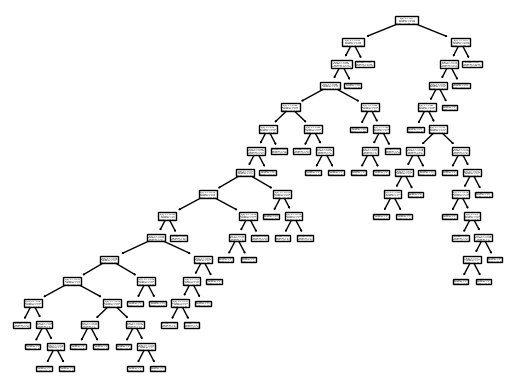

In [39]:
tree.plot_tree(dt1)

In [40]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [41]:
accuracy_score(y_test,y_pred)

0.9800936768149883

[[508  10]
 [  7 329]]


Text(50.722222222222214, 0.5, 'Actual Values')

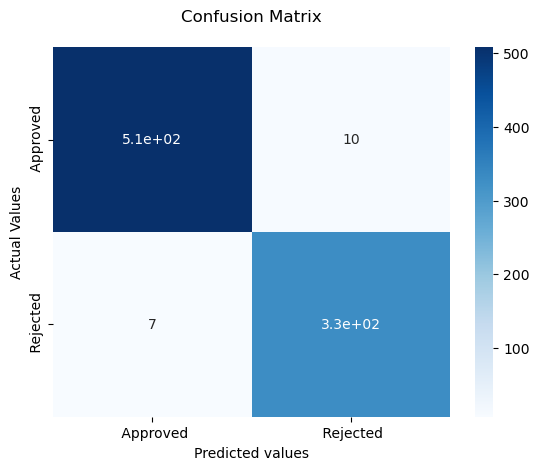

In [42]:
cm = confusion_matrix(y_test,y_pred)
print(cm)
sns.heatmap(cm,annot=True,cmap='Blues',yticklabels=[' Approved', ' Rejected'],xticklabels=[' Approved', ' Rejected'])
plt.title('Confusion Matrix\n')
plt.xlabel('Predicted values')
plt.ylabel('Actual Values')

In [43]:
le.classes_

array([' Approved', ' Rejected'], dtype=object)

In [44]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       518
           1       0.97      0.98      0.97       336

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [45]:
from sklearn.metrics import roc_curve, auc

In [46]:
y_prob = dt1.predict_proba(x_test)[:, 1]

In [47]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [48]:
roc_auc = auc(fpr, tpr)

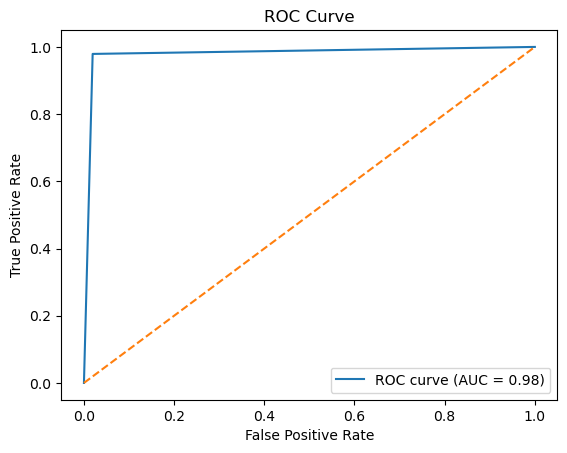

In [49]:
plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()